## Figure XX - iPSC controls (wtNb and PuroR)

In [2]:
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
from matplotlib.patches import Patch
import scipy

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

## Load in Data + gating

In [3]:
base_path = rd.datadir/'data'/'attune'/'Derin'
output_path = rd.rootdir/'output'/'Figure_XX_iPSCs'

plates = pd.DataFrame({'data_path': ['2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1/CSV', '2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV'], 
                       'yaml_path': ['2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1/CSV/wells_metadata.yaml', '2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV/wells_metadata.yaml'],
                       'plate':range(1,3)})

display(plates)

,data_path,yaml_path,plate
0,2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1...,2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1...,1
1,2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4...,2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4...,2


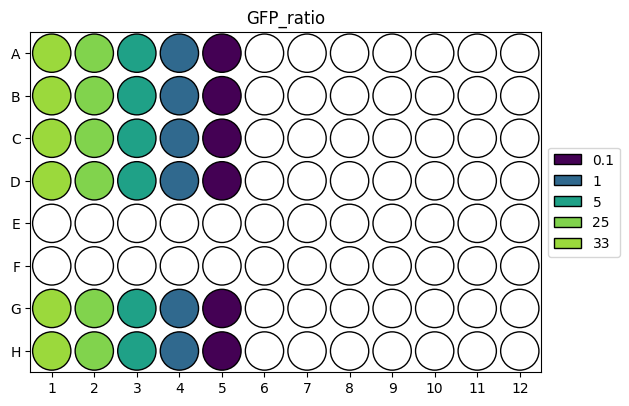

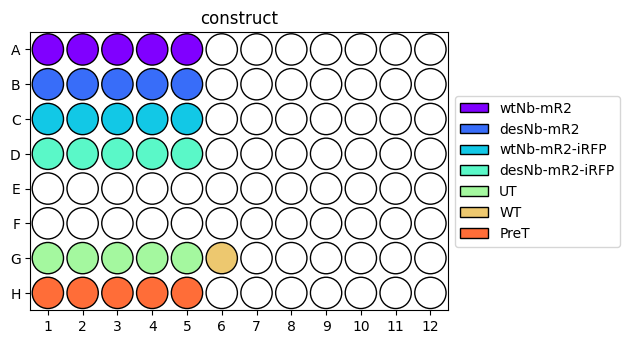

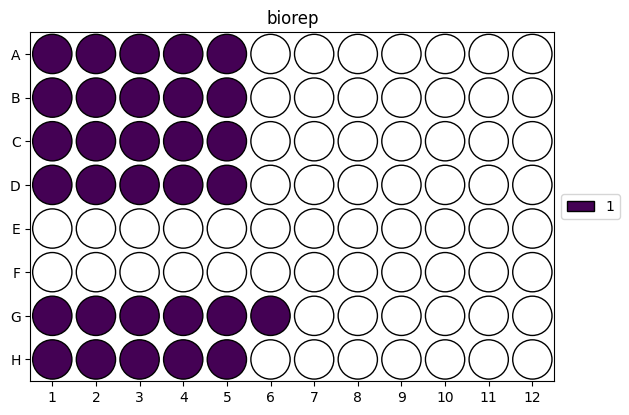

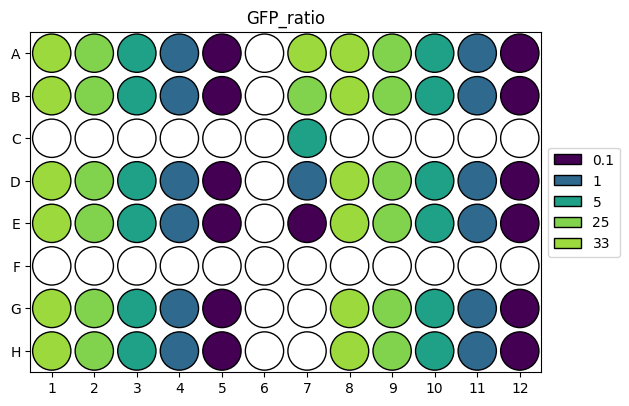

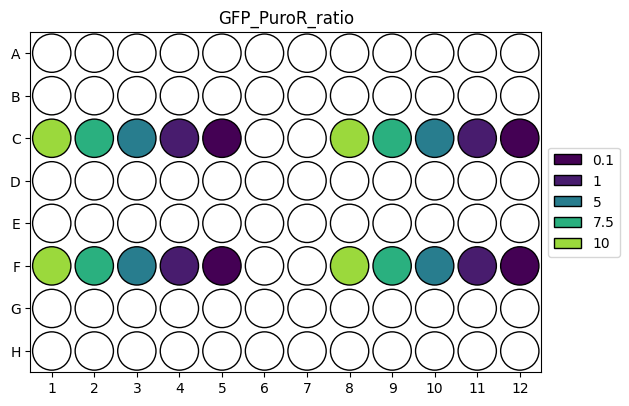

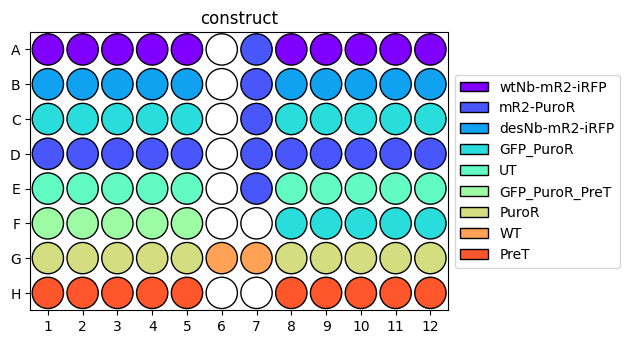

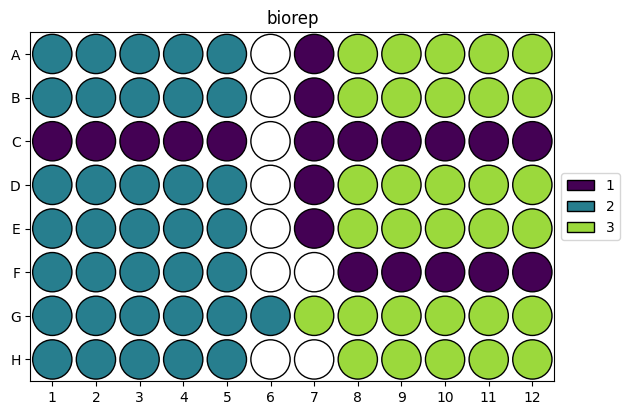

In [4]:
for p in plates['yaml_path'].unique():
    rd.plot.plot_well_metadata(base_path/p)


In [5]:
#Specify which channels to load
data = pd.DataFrame()
channel_list = ['mRuby2-A', 'iRFP670-A', 'EGFP-A', 'TagBFP-A']

#load data
data = rd.flow.load_groups_with_metadata(plates, base_path, columns=channel_list)

display(data)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore


,GFP_ratio,construct,biorep,well,population,EGFP-A,iRFP670-A,TagBFP-A,mRuby2-A,plate,GFP_PuroR_ratio
0,33.0,wtNb-mR2,1,A1,Single Cells,17.0,136,56,386.0,1,<NA>
1,33.0,wtNb-mR2,1,A1,Single Cells,39524.0,33,248,674.0,1,<NA>
2,33.0,wtNb-mR2,1,A1,Single Cells,82.0,-105,-69,445.0,1,<NA>
3,33.0,wtNb-mR2,1,A1,Single Cells,109.0,-61,170,287.0,1,<NA>
4,33.0,wtNb-mR2,1,A1,Single Cells,-209.0,12,239,189.0,1,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
14865252,25.0,PreT,3,H9,Single Cells,116.0,54,91,83.0,2,<NA>
14865253,25.0,PreT,3,H9,Single Cells,105.0,76,11,125.0,2,<NA>
14865254,25.0,PreT,3,H9,Single Cells,136.0,-44,131,196.0,2,<NA>
14865255,25.0,PreT,3,H9,Single Cells,9506.0,179,276,-67.0,2,<NA>


In [6]:
#Mapping new names to the dilution ratios for easier interpretation in the plots and creating a conditions column for plotting
# Map the two dilution schemes to readable GFP:WT ratios
ratio_map = {33: '1:2', 25: '1:3', 5: '1:19', 1: '1:99', 0.1: '1:999'}

GFP_PuroR_ratio_map = {10: '1:9', 7.5: '1:12',5: '1:19',1: '1:99',0.1: '1:999'}

# Preserve numeric versions of both metadata columns
data['GFP_ratio_raw'] = pd.to_numeric(data['GFP_ratio'], errors='coerce')

data['GFP_PuroR_ratio_raw'] = pd.to_numeric(data['GFP_PuroR_ratio'], errors='coerce')

# Map each dilution scheme separately
data['GFP_ratio_label'] = data['GFP_ratio_raw'].map(ratio_map)

data['GFP_PuroR_ratio_label'] = (data['GFP_PuroR_ratio_raw'].map(GFP_PuroR_ratio_map))

# Use the GFP_PuroR-specific ratio when present;
# otherwise use the standard GFP ratio
data['dilution_ratio'] = (data['GFP_PuroR_ratio_label'].combine_first(data['GFP_ratio_label']))

# Create plotting condition labels
data['condition'] = (data['construct'].astype(str)+ ' | '+ data['dilution_ratio'].fillna(''))

data['condition'] = data['condition'].str.rstrip(' |')

display(data)

,GFP_ratio,construct,biorep,well,population,EGFP-A,iRFP670-A,TagBFP-A,mRuby2-A,plate,GFP_PuroR_ratio,GFP_ratio_raw,GFP_PuroR_ratio_raw,GFP_ratio_label,GFP_PuroR_ratio_label,dilution_ratio,condition
0,33.0,wtNb-mR2,1,A1,Single Cells,17.0,136,56,386.0,1,<NA>,33.0,NaN,1:2,NaN,1:2,wtNb-mR2 | 1:2
1,33.0,wtNb-mR2,1,A1,Single Cells,39524.0,33,248,674.0,1,<NA>,33.0,NaN,1:2,NaN,1:2,wtNb-mR2 | 1:2
2,33.0,wtNb-mR2,1,A1,Single Cells,82.0,-105,-69,445.0,1,<NA>,33.0,NaN,1:2,NaN,1:2,wtNb-mR2 | 1:2
3,33.0,wtNb-mR2,1,A1,Single Cells,109.0,-61,170,287.0,1,<NA>,33.0,NaN,1:2,NaN,1:2,wtNb-mR2 | 1:2
4,33.0,wtNb-mR2,1,A1,Single Cells,-209.0,12,239,189.0,1,<NA>,33.0,NaN,1:2,NaN,1:2,wtNb-mR2 | 1:2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14865252,25.0,PreT,3,H9,Single Cells,116.0,54,91,83.0,2,<NA>,25.0,NaN,1:3,NaN,1:3,PreT | 1:3
14865253,25.0,PreT,3,H9,Single Cells,105.0,76,11,125.0,2,<NA>,25.0,NaN,1:3,NaN,1:3,PreT | 1:3
14865254,25.0,PreT,3,H9,Single Cells,136.0,-44,131,196.0,2,<NA>,25.0,NaN,1:3,NaN,1:3,PreT | 1:3
14865255,25.0,PreT,3,H9,Single Cells,9506.0,179,276,-67.0,2,<NA>,25.0,NaN,1:3,NaN,1:3,PreT | 1:3


In [7]:
pos_cols = [f'{ch}_positive' for ch in channel_list]
data[pos_cols] = data[channel_list].gt(0).to_numpy()

agg = {'cell_count':(channel_list[0], 'size')}
if 'well' in data.columns: agg['well_count'] = ('well', 'nunique')
agg |= {f'{ch}_percent_positive':(f'{ch}_positive', 'mean') for ch in channel_list}

summary = (data.groupby(['condition', 'construct', 'dilution_ratio', 'biorep'], dropna=False)
          .agg(**agg).reset_index())

pct_cols = [c for c in summary.columns if c.endswith('_percent_positive')]
summary[pct_cols] *= 100

display(summary)

,condition,construct,dilution_ratio,biorep,cell_count,well_count,mRuby2-A_percent_positive,iRFP670-A_percent_positive,EGFP-A_percent_positive,TagBFP-A_percent_positive
0,GFP_PuroR | 1:12,GFP_PuroR,1:12,1,323213,3,84.626547,78.786435,95.394059,95.397462
1,GFP_PuroR | 1:19,GFP_PuroR,1:19,1,244564,3,84.536972,77.776369,97.409676,95.601560
2,GFP_PuroR | 1:9,GFP_PuroR,1:9,1,436240,3,84.386805,79.283193,92.650376,95.203328
3,GFP_PuroR | 1:99,GFP_PuroR,1:99,1,646671,3,83.646708,80.937911,93.856227,94.961580
4,GFP_PuroR | 1:999,GFP_PuroR,1:999,1,115296,3,82.546663,75.457084,95.750937,95.004163
...,...,...,...,...,...,...,...,...,...,...
103,wtNb-mR2-iRFP | 1:99,wtNb-mR2-iRFP,1:99,2,19921,1,90.577782,85.974600,88.936298,89.558757
104,wtNb-mR2-iRFP | 1:99,wtNb-mR2-iRFP,1:99,3,96931,1,92.398717,83.821481,86.150973,88.582600
105,wtNb-mR2-iRFP | 1:999,wtNb-mR2-iRFP,1:999,1,131765,1,93.255417,49.381854,88.174401,88.917391
106,wtNb-mR2-iRFP | 1:999,wtNb-mR2-iRFP,1:999,2,182700,1,92.573071,82.354680,88.097975,89.082102


In [8]:
#From the summary plot one of the condiitons was identified as having too low of a cell count, now we must remove that from the dataframe
min_cells = 100

# Find condition/biorep combinations with too few cells
bad_groups = summary.loc[summary['cell_count'] < min_cells, ['condition', 'biorep']]
bad_groups['exclude'] = True

# Mark matching rows in the large dataframe
data_plot = data.merge(bad_groups, on=['condition', 'biorep'], how='left')

# Keep rows that were not marked for exclusion
data_plot = data_plot.loc[data_plot['exclude'].isna()].drop(columns='exclude')

display(bad_groups)
print('Original events:', len(data))
print('Events after QC:', len(data_plot))

,condition,biorep,exclude


Original events: 14865257
Events after QC: 14865257


In [9]:
#GFP_thresh = 1e3
GFP_thresh = data_plot.loc[data_plot.construct == 'WT', 'EGFP-A'].quantile(0.999)

def summarize_gfp_percent(data, ratio_col):
    gfp_data = data.loc[data[ratio_col].notna()].copy() #filters data to only keep rows where the selected ratio column is NOT missing
    gfp_data['EGFP_positive'] = gfp_data['EGFP-A'] > GFP_thresh #create a new column that is booleans 

    df = (gfp_data.groupby(['construct', ratio_col, 'biorep']).agg(cell_count=('EGFP-A', 'size'), percent=('EGFP_positive', 'mean')).reset_index()
          .rename(columns={ratio_col:'ratio'}))
    df['percent'] *= 100
    return df

df_gfp_percent = summarize_gfp_percent(data_plot, 'GFP_ratio_label')
df_gfp_puror_percent = summarize_gfp_percent(data_plot, 'GFP_PuroR_ratio_label')

display(df_gfp_percent)
display(df_gfp_puror_percent)

,construct,ratio,biorep,cell_count,percent
0,PreT,1:19,1,45281,7.764846
1,PreT,1:19,2,81389,8.162037
2,PreT,1:19,3,117969,7.047614
3,PreT,1:2,1,46676,46.336447
4,PreT,1:2,2,100821,45.232640
...,...,...,...,...,...
90,wtNb-mR2-iRFP,1:99,2,19921,1.395512
91,wtNb-mR2-iRFP,1:99,3,96931,2.270687
92,wtNb-mR2-iRFP,1:999,1,131765,0.084241
93,wtNb-mR2-iRFP,1:999,2,182700,0.302682


,construct,ratio,biorep,cell_count,percent
0,GFP_PuroR,1:12,1,323213,92.648811
1,GFP_PuroR,1:19,1,244564,94.901539
2,GFP_PuroR,1:9,1,436240,89.653173
3,GFP_PuroR,1:99,1,646671,90.099602
4,GFP_PuroR,1:999,1,115296,89.217319
5,GFP_PuroR_PreT,1:12,2,46680,6.403171
6,GFP_PuroR_PreT,1:19,2,60076,4.149744
7,GFP_PuroR_PreT,1:9,2,46080,10.970052
8,GFP_PuroR_PreT,1:99,2,61187,0.933205
9,GFP_PuroR_PreT,1:999,2,81282,0.141483


# Figure XX iPSC Graph

1:19_wtNb-mR2-iRFP vs. 1:19_desNb-mR2-iRFP: ****
1:99_wtNb-mR2-iRFP vs. 1:99_desNb-mR2-iRFP: ****
1:3_wtNb-mR2-iRFP vs. 1:3_desNb-mR2-iRFP: **
1:2_wtNb-mR2-iRFP vs. 1:2_desNb-mR2-iRFP: **
1:999_wtNb-mR2-iRFP vs. 1:999_desNb-mR2-iRFP: ****


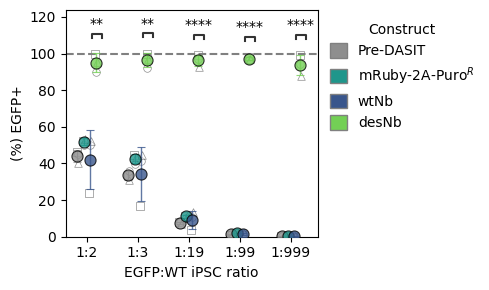

In [10]:
hue = 'construct'
order = ['1:2', '1:3', '1:19', '1:99', '1:999']
ratio_order = ['1:2', '1:3', '1:19', '1:99', '1:999']

# General plotting params
x = 'ratio'
y = 'percent'

palette = {
    "PreT": "#8E8E8E",
    "wtNb-mR2-iRFP": "#39568CFF",
    "mR2-PuroR": '#1F968BFF',
    "desNb-mR2-iRFP": "#73D055FF"
}

hue_order = [
    "PreT",
    'mR2-PuroR',
    "wtNb-mR2-iRFP",
    'desNb-mR2-iRFP'
]

subset = df_gfp_percent[df_gfp_percent['construct'].isin(hue_order)]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['construct', 'ratio', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['construct', 'ratio'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(5,3))

colors = palette

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(ratio_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

# Small offsets for the three constructs
offsets = np.linspace(-0.18, 0.18, len(hue_order))

# Tiny jitter for each biological replicate
rep_offsets = np.linspace(-0.02, 0.02, len(markers))

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, ratio in enumerate(ratio_order):
        for j, construct in enumerate(hue_order):

            row = rep_data[
                (rep_data["ratio"] == ratio) &
                (rep_data["construct"] == construct)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j] + rep_offsets[rep]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2,
            )

# Biological replicate mean dots (front layer)


for i, ratio in enumerate(ratio_order):
    for j, construct in enumerate(hue_order):

        row = summary[
            (summary["ratio"] == ratio) &
            (summary["construct"] == construct)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt='o',
            markersize=8,
            color=colors[construct],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )
# Formatting

ax.yaxis.set_label_text('(%) EGFP+')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)


label_map = {'PreT':'Pre-DASIT', 
            'UT':'UT', 
            'PuroR':'PuroR',
             'mR2-PuroR':'mRuby-2A-Puro$^R$',
             'wtNb-mR2-iRFP':'wtNb',
             'desNb-mR2-iRFP':'desNb',
             'GFP_PuroR_PreT':'Pre-Selection',
             'GFP_PuroR':'Post-Selection'}

ax.set_xticks(group_centers)
ax.set_xticklabels(ratio_order)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[construct],
        edgecolor='grey',
        label=label_map.get(construct, construct)
    )
    for construct in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Construct',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests: wtNb vs desNb for each ratio

pairs = [
    ((ratio, "wtNb-mR2-iRFP"), (ratio, "desNb-mR2-iRFP"))
    for ratio in ratio_order
]

annotations = []

for ratio in ratio_order:

    vals1 = bio_means.loc[
        (bio_means["ratio"] == ratio) &
        (bio_means["construct"] == "wtNb-mR2-iRFP"),
        y
    ]

    vals2 = bio_means.loc[
        (bio_means["ratio"] == ratio) &
        (bio_means["construct"] == "desNb-mR2-iRFP"),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=bio_means,
    x="ratio",
    y=y,
    hue="construct",
    order=ratio_order,
    hue_order=hue_order,
)

annotator.configure(
    test="t-test_ind",
    text_format="full",
    loc="inside",
    line_height=0.02,
    text_offset=2,
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
ax.set_xlabel('EGFP:WT iPSC ratio')


fig.tight_layout()

plottitle = 'Figure_XX_iPSCs_controls_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

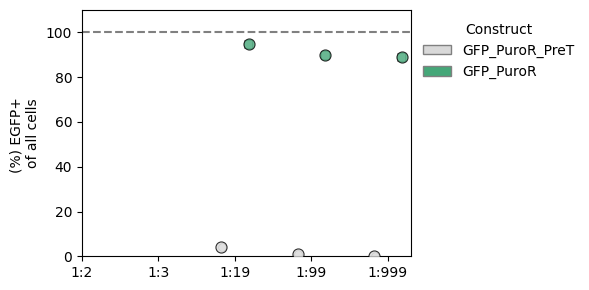

In [31]:
hue = 'construct'
order = ['1:2', '1:3', '1:19', '1:99', '1:999']
ratio_order = ['1:2', '1:3', '1:19', '1:99', '1:999']

# General plotting params
x = 'ratio'
y = 'percent'

palette = {
    "GFP_PuroR_PreT": "#D9D9D9",
    "GFP_PuroR": "#45A778"
}

hue_order = ['GFP_PuroR_PreT', 'GFP_PuroR']

subset = df_gfp_puror_percent[df_gfp_puror_percent['construct'].isin(hue_order)]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['construct', 'ratio', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['construct', 'ratio'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = palette

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(ratio_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

# Small offsets for the three constructs
offsets = np.linspace(-0.18, 0.18, len(hue_order))

# Tiny jitter for each biological replicate
rep_offsets = np.linspace(-0.02, 0.02, len(markers))

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, ratio in enumerate(ratio_order):
        for j, construct in enumerate(hue_order):

            row = rep_data[
                (rep_data["ratio"] == ratio) &
                (rep_data["construct"] == construct)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j] + rep_offsets[rep]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2,
            )

# Biological replicate mean dots (front layer)


for i, ratio in enumerate(ratio_order):
    for j, construct in enumerate(hue_order):

        row = summary[
            (summary["ratio"] == ratio) &
            (summary["construct"] == construct)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt='o',
            markersize=8,
            color=colors[construct],
            alpha=0.8,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )
# Formatting

ax.yaxis.set_label_text('(%) EGFP+ \nof all cells')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)


label_map = {'PreT':'Pre-DASIT', 
            'UT':'UT', 
            'PuroR':'PuroR',
             'mR2-PuroR':'mR2-PuroR',
             'wtNb-mR2-iRFP':'wtNb-mR2-iRFP',
             'desNb-mR2-iRFP':'desNb-mR2-iRFP',
             'GFP_PuroR_PreT':'Pre-Selection',
             'GFP_PuroR':'Post-Selection'}

ax.set_xticks(group_centers)
ax.set_xticklabels(ratio_order)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p}'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Construct',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests: wtNb vs desNb for each ratio

# pairs = [
#     ((ratio, "wtNb-mR2-iRFP"), (ratio, "desNb-mR2-iRFP"))
#     for ratio in ratio_order
# ]

# annotations = []

# for ratio in ratio_order:

#     vals1 = bio_means.loc[
#         (bio_means["ratio"] == ratio) &
#         (bio_means["construct"] == "wtNb-mR2-iRFP"),
#         y
#     ]

#     vals2 = bio_means.loc[
#         (bio_means["ratio"] == ratio) &
#         (bio_means["construct"] == "desNb-mR2-iRFP"),
#         y
#     ]

#     _, p = ttest_ind(vals1, vals2)

#     if p < 1e-4:
#         stars = "****"
#     elif p < 1e-3:
#         stars = "***"
#     elif p < 1e-2:
#         stars = "**"
#     elif p < 0.05:
#         stars = "*"
#     else:
#         stars = "ns"

#     annotations.append(stars)


# annotator = Annotator(
#     ax,
#     pairs=pairs,
#     data=bio_means,
#     x="ratio",
#     y=y,
#     hue="construct",
#     order=ratio_order,
#     hue_order=hue_order,
# )

# annotator.configure(
#     test="t-test_ind",
#     text_format="full",
#     loc="inside",
#     line_height=0.02,
#     text_offset=2,
# )

# annotator.set_custom_annotations(annotations)
# annotator.annotate()


fig.tight_layout()

plottitle = 'Figure_XX_iPSCs_controls_puroR_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')